In [1]:
include("functions.jl")
using Plots, JLD2, LaTeXStrings, FileIO

### Analyzing Single Trajectory

In [5]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/dephase_1.0e-5/N_atoms=5_γ_dephase=1.0e-5_Ntraj=1.jld2"

ψt_end = ψt_end;
ψ_target = ψ_target;

In [29]:
# ρt_end = ψt_end.data * ψt_end.data'
ρ = ptrace(ψt_end,[4,5])

full_basis = CompositeBasis([NLevelBasis(3) for _ in 1:total_qubits]...)
plus = sqrt(1/2) .* a + sqrt(1/2) .* b
minus = sqrt(1/2) .* a - sqrt(1/2) .* b
ψ_target = α .* reduce(kron,[plus,plus,plus,a,a]) - β .* reduce(kron,[minus,minus,minus,a,a])

ρ_target = ptrace(Ket(full_basis,ψ_target),[4,5]);
# ρ_target = ψ_target * ψ_target';

Operator(dim=27x27)
  basis: [NLevel(N=3) ⊗ NLevel(N=3) ⊗ NLevel(N=3)]
 0.5+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
    ⋮                             ⋱                ⋮       
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+

In [30]:
real(tr(sqrt(sqrt(ρ.data)*ρ_target.data*sqrt(ρ.data)))^2)

0.9991568991319759

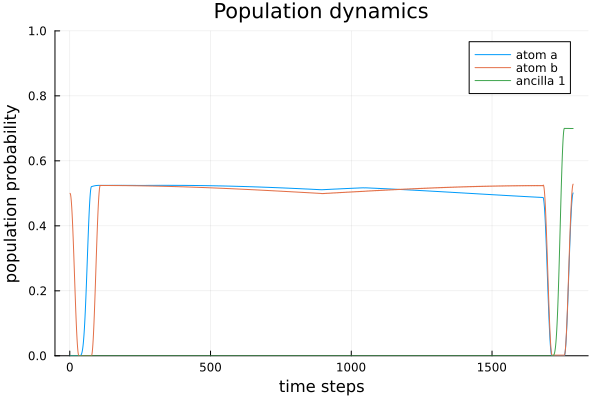

In [ ]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.01_Ntraj=12.jld2"

population_data = population_data;
corrected_population_data = corrected_population_data;
final_step_population_data = final_step_population_data;
S1_data = S1_data;
S2_data = S2_data;
end_time = end_time;

# t1 = tspan1[end]+tspan2[end]+tspan2[end]+tspan3[end]
# t = [0.0:0.1:683.8;]
# t2 = [t[end]:0.1:(t[end]+tspan2[end]);]

plot(population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(population_data[:b], label="atom b")
# plot!(population_data[:c], label="atom c")
plot!(population_data[:a1], label="ancilla 1")
# plot!(population_data[:a2], label="ancilla 2")

In [42]:
end_time

83.9624719619751

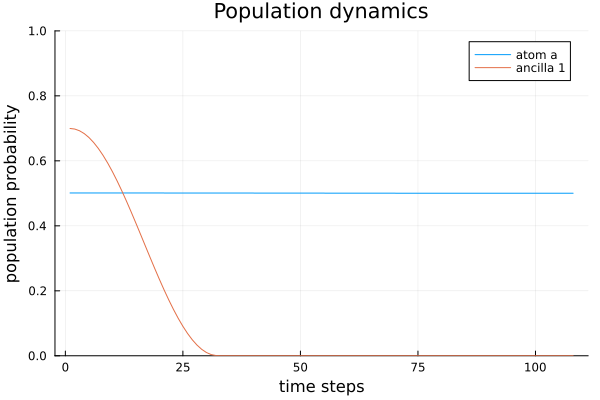

In [37]:
plot(corrected_population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
# plot(corrected_population_data[:b], label="atom b")
# plot(corrected_population_data[:c], label="atom c")
plot!(corrected_population_data[:a1], label="ancilla 1")
# plot!(corrected_population_data[:a2], label="ancilla 2")

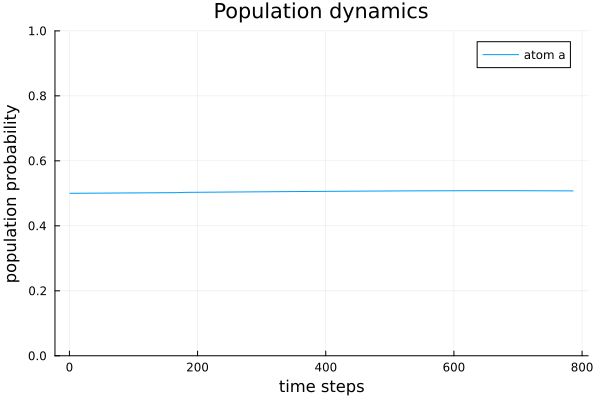

In [38]:
plot(final_step_population_data[:a],ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
# plot(corrected_population_data[:b], label="atom b")
# plot(corrected_population_data[:c], label="atom c")

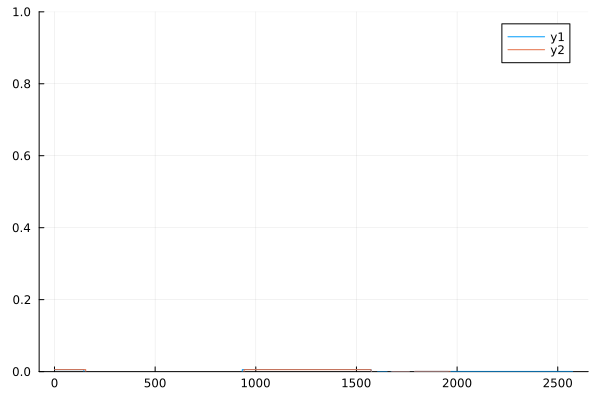

In [39]:
plot(S1_data,ylim=[0,1])
plot!(S2_data,ylim=[0,1])

### Average Trajectory analysis

In [5]:
((2 + sqrt(2))π + 25π + 25π + (2 + sqrt(2))π + (2 + sqrt(2))π +25π)

267.79765375524835

In [6]:
0.5 / ((2 + sqrt(2))π + 25π + 25π + (2 + sqrt(2))π + (2 + sqrt(2))π +25π)

0.0018670813317019246

In [12]:
P_no_error = (1 - ((1 - exp(-0.01*268))))^5;
P_1_error = 5*(1 - exp(-0.01*268))*(1 - ((1 - exp(-0.01*268))))^4;
P_2_error = 10*(1 - exp(-0.01*268))^2*(1 - ((1 - exp(-0.01*268))))^3

println("Probability of no errors: ", P_no_error)
println("Probability of 1 atom errors: ", P_1_error)
println("Probability of 2 atom errors: ", P_2_error)

Probability of no errors: 1.5151441121432517e-6
Probability of 1 atom errors: 0.00010291687060085267
Probability of 2 atom errors: 0.0027962705776653474


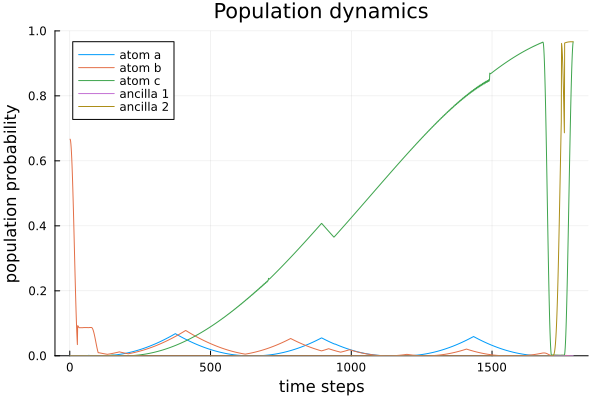

In [20]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.1_Ntraj=1.jld2"
fidelity_after_encoding = fidelity_after_encoding;
fidelity_after_correction = fidelity_after_correction;

population_data = population_data;
corrected_population_data = corrected_population_data;
final_step_population_data = final_step_population_data;
S1_data = avg_S1_data;
S2_data = avg_S2_data;

plot(population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(population_data[:b], label="atom b")
plot!(population_data[:c], label="atom c")
plot!(population_data[:a1], label="ancilla 1")
plot!(population_data[:a2], label="ancilla 2")

# plot(corrected_population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
# plot(corrected_population_data[:b], label="atom b")
# plot(corrected_population_data[:c], label="atom c")
# plot!(corrected_population_data[:a1], label="ancilla 1")
# plot!(corrected_population_data[:a2], label="ancilla 2")

# plot(final_step_population_data[:a],ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
# plot!(final_step_population_data[:b], label="atom b")
# plot!(final_step_population_data[:c], label="atom c")

# plot(S1_data,ylim=[0,1])
# plot!(S2_data,ylim=[0,1])

### dephasing rate = 0.1

Fidelity after encoding: 0.10834101807916234
Fidelity after correction: 0.3715252930599034


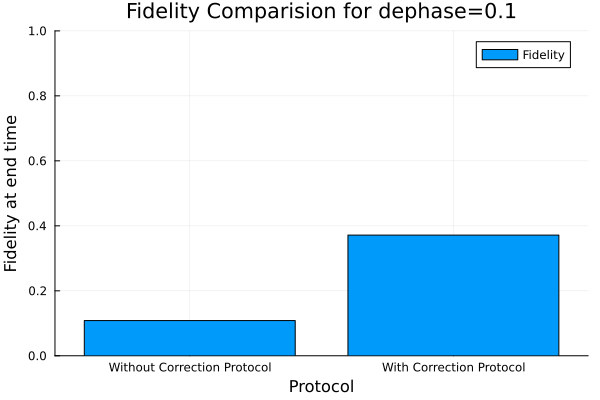

In [2]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.1_Ntraj=1000_avg.jld2"

avg_fidelity_after_encoding = avg_fidelity_after_encoding;
avg_fidelity_after_correction = avg_fidelity_after_correction;

# avg_population_data = avg_population_data;
# avg_corrected_population_data = avg_corrected_population_data;
# avg_final_step_population_data = avg_final_step_population_data;
# avg_S1_data = avg_S1_data;
# avg_S2_data = avg_S2_data;

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [avg_fidelity_after_encoding, avg_fidelity_after_correction]

println("Fidelity after encoding: ", avg_fidelity_after_encoding)
println("Fidelity after correction: ", avg_fidelity_after_correction)
bar(x,y, ylim=[0,1], label="Fidelity", title="Fidelity Comparision for dephase=0.1", xlabel="Protocol", ylabel="Fidelity at end time")

### dephasing rate = 0.01

Fidelity after encoding: 0.2739432636027808
Fidelity after correction: 0.6453574484176743


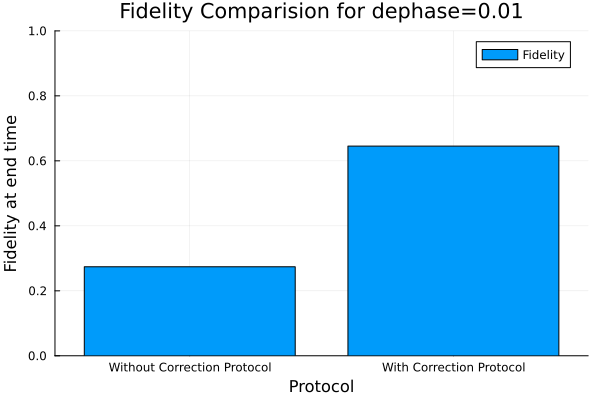

In [2]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.01_Ntraj=1000_avg.jld2"

avg_fidelity_after_encoding = avg_fidelity_after_encoding;
avg_fidelity_after_correction = avg_fidelity_after_correction;

# avg_population_data = avg_population_data;
# avg_corrected_population_data = avg_corrected_population_data;
# avg_final_step_population_data = avg_final_step_population_data;
# avg_S1_data = avg_S1_data;
# avg_S2_data = avg_S2_data;

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [avg_fidelity_after_encoding, avg_fidelity_after_correction]

println("Fidelity after encoding: ", avg_fidelity_after_encoding)
println("Fidelity after correction: ", avg_fidelity_after_correction)
bar(x,y, ylim=[0,1], label="Fidelity", title="Fidelity Comparision for dephase=0.01", xlabel="Protocol", ylabel="Fidelity at end time")

### dephasing rate = 0.001

Fidelity after encoding: 0.8090896351205943
Fidelity after correction: 0.9263080741172368


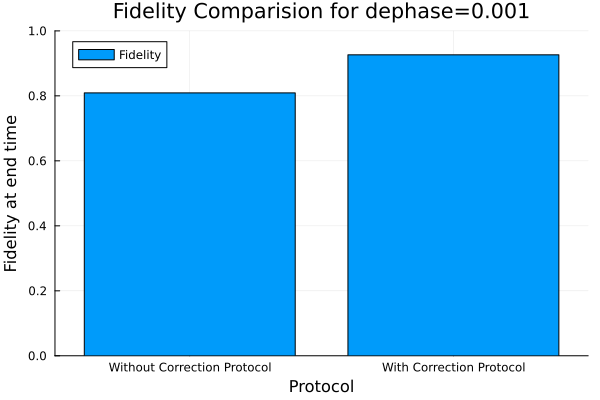

In [4]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.001_Ntraj=1000_avg.jld2"

avg_fidelity_after_encoding = avg_fidelity_after_encoding;
avg_fidelity_after_correction = avg_fidelity_after_correction;

# avg_population_data = avg_population_data;
# avg_corrected_population_data = avg_corrected_population_data;
# avg_final_step_population_data = avg_final_step_population_data;
# avg_S1_data = avg_S1_data;
# avg_S2_data = avg_S2_data;

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [avg_fidelity_after_encoding, avg_fidelity_after_correction]

println("Fidelity after encoding: ", avg_fidelity_after_encoding)
println("Fidelity after correction: ", avg_fidelity_after_correction)
bar(x,y, ylim=[0,1], label="Fidelity", title="Fidelity Comparision for dephase=0.001", xlabel="Protocol", ylabel="Fidelity at end time")

### dephasing rate = 0.0001

Fidelity after encoding: 0.9774576786648207
Fidelity after correction: 0.9916949021890608


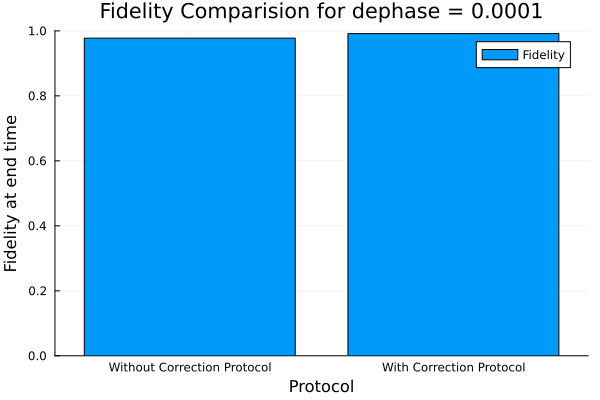

In [5]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.0001_Ntraj=1000_avg.jld2"

avg_fidelity_after_encoding = avg_fidelity_after_encoding;
avg_fidelity_after_correction = avg_fidelity_after_correction;

# avg_population_data = avg_population_data;
# avg_corrected_population_data = avg_corrected_population_data;
# avg_final_step_population_data = avg_final_step_population_data;
# avg_S1_data = avg_S1_data;
# avg_S2_data = avg_S2_data;

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [avg_fidelity_after_encoding, avg_fidelity_after_correction]

println("Fidelity after encoding: ", avg_fidelity_after_encoding)
println("Fidelity after correction: ", avg_fidelity_after_correction)

bar(x,y, ylim=[0,1], label="Fidelity", title="Fidelity Comparision for dephase = 0.0001", xlabel="Protocol", ylabel="Fidelity at end time")

### dephasing rate = 0.00001

Fidelity after encoding: 0.9956246457535005
Fidelity after correction: 0.9974863357733823


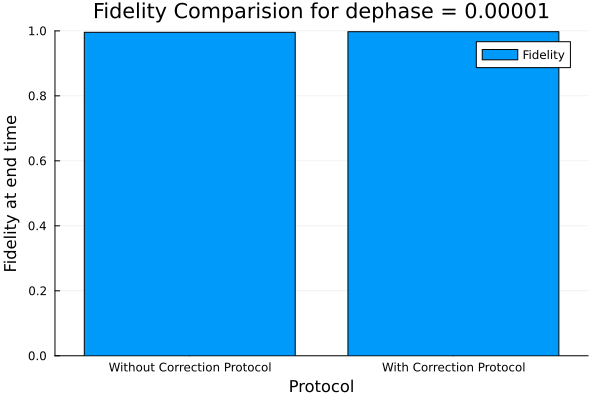

In [6]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_dephase=0.00001_Ntraj=1000_avg.jld2"

avg_fidelity_after_encoding = avg_fidelity_after_encoding;
avg_fidelity_after_correction = avg_fidelity_after_correction;

# avg_population_data = avg_population_data;
# avg_corrected_population_data = avg_corrected_population_data;
# avg_final_step_population_data = avg_final_step_population_data;
# avg_S1_data = avg_S1_data;
# avg_S2_data = avg_S2_data;

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [avg_fidelity_after_encoding, avg_fidelity_after_correction]

println("Fidelity after encoding: ", avg_fidelity_after_encoding)
println("Fidelity after correction: ", avg_fidelity_after_correction)

bar(x,y, ylim=[0,1], label="Fidelity", title="Fidelity Comparision for dephase = 0.00001", xlabel="Protocol", ylabel="Fidelity at end time")